# 静息态 EEG 频域分析 - 多被试批量处理

批量处理所有被试，进行组平均和组水平统计

**分析内容:**
- 功率谱密度 (PSD) 计算
- 信噪比 (SNR) 分析
- 频段功率 (Delta, Theta, Alpha, Beta, Gamma)
- 相对功率分析
- 组平均可视化

## 变量参考表 (Variable Reference)

### 分组配置变量 (Group Configuration)
| 变量名 | 类型 | 说明 | 定义位置 |
|--------|------|------|----------|
| `GROUP_NAME` | `str` | 当前分析组 ('com'/'std'/'all') | setup |
| `GROUP_PREFIX` | `Dict[str, str]` | 组别前缀映射 {'com': 'com_', 'std': 'std_'} | setup |
| `SUBJECT_GROUPS` | `Dict[str, List]` | 被试分组定义 (不含前缀) | setup |

### 路径配置变量 (Path Configuration)
| 变量名 | 类型 | 说明 | 定义位置 |
|--------|------|------|----------|
| `DATA_ROOT` | `Path` | 项目根目录 | setup |
| `EPOCH_DATA_PATH` | `Path` | 预处理epoch数据目录 | setup |
| `OUTPUT_PATH` | `Path` | 输出目录 (按组分开) | setup |
| `RESULTS_PATH` | `Path` | 结果文件目录 | setup |
| `FIGURES_PATH` | `Path` | 图片输出目录 | setup |

### 分析参数变量 (Analysis Parameters)
| 变量名 | 类型 | 说明 | 定义位置 |
|--------|------|------|----------|
| `SUB_IDS` | `List[str]` | 被试ID列表 (带前缀) | setup |
| `BANDS` | `Dict[str, Tuple]` | 频段定义 {名称: (fmin, fmax)} | setup |
| `TARGET_SFREQ` | `int` | 目标采样率 500Hz | setup |
| `TARGET_SAMPLES` | `int` | 目标采样点数 5000 | setup |

### 数据变量 (Data)
| 变量名 | 类型 | Shape | 说明 | 定义位置 |
|--------|------|-------|------|----------|
| `list_psds` | `List[ndarray]` | [(n_ch, n_freqs), ...] | 各被试PSD | batch_loop |
| `psds_group` | `ndarray` | (n_ch, n_freqs) | 组平均PSD | group_average |
| `band_powers_group` | `Dict[str, ndarray]` | {band: (n_ch,)} | 组平均频段功率 | group_average |
| `stats_df` | `DataFrame` | (n_bands, 4) | 描述性统计 | statistics |

### 输出变量 (Output)
| 变量名 | 类型 | 说明 | 保存路径 |
|--------|------|------|----------|
| `group_results` | `Dict` | 组分析结果 | `{GROUP}/results/group_frequency_results.pkl` |
| `stats_df` | `DataFrame` | 描述性统计 | `{GROUP}/results/frequency_stats.csv` |

### 数据血缘概览 (Data Lineage Overview)
```
GROUP_NAME → get_subject_ids() → SUB_IDS
                                    ↓
EPOCH_DATA_PATH → load_epochs() → epochs
                                    ↓
                        compute_psd() → list_psds
                                    ↓
                            组平均 → psds_group, band_powers_group
                                    ↓
                                可视化 + 统计
```

In [89]:
%matplotlib inline

# 导入必要的库
import os
import os.path as op
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import warnings

import mne
import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm.notebook import tqdm
import pandas as pd

# 忽略MNE的一些警告
warnings.filterwarnings('ignore', category=RuntimeWarning)

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print(f"MNE版本: {mne.__version__}")
print(f"NumPy版本: {np.__version__}")

MNE版本: 1.8.0
NumPy版本: 1.23.5


In [90]:
# =============================================================================
# 被试分组配置
# =============================================================================
# GROUP_NAME: str - 当前分析的被试组名称
# 可选: 'adhd', 'com' (共患), 'td' (典型发展), 'all' (所有被试)
GROUP_NAME: str = 'adhd'

# SUBJECT_GROUPS: Dict[str, List[str]] - 被试ID列表
SUBJECT_GROUPS: Dict[str, List[str]] = {
    'adhd': ['018', '029', '031', '037', '038', '045', '075', '091', '094', '117', '132', '134'],
    'com': ['001', '020', '021', '022', '024', '047', '049', '051', '072', '073', '076', '092', '113', '150'],
    'td': ['006', '068', '079', '093', '108', '109', '127', '133'],
}

# =============================================================================
# 数据路径配置
# =============================================================================
# DATA_ROOT: Path - 项目根目录
DATA_ROOT: Path = Path(r'd:\LYW\REST_COM')

# EPOCH_DATA_PATH: Path - 预处理后的epoch数据目录 (按组分子目录: adhd/, com/, td/)
EPOCH_DATA_PATH: Path = DATA_ROOT / 'preprocessing' / 'data' / '6epoch_clean'

# =============================================================================
# 根据GROUP_NAME生成被试列表
# =============================================================================
def get_subject_ids(group_name: str) -> List[str]:
    """根据组名返回被试ID列表"""
    if group_name == 'all':
        sub_ids = []
        for group, ids in SUBJECT_GROUPS.items():
            sub_ids.extend(ids)
        return sub_ids
    else:
        return list(SUBJECT_GROUPS.get(group_name, []))

def get_group_from_id(sub_id: str) -> str:
    """从被试ID查找所属组别"""
    for group, ids in SUBJECT_GROUPS.items():
        if sub_id in ids:
            return group
    return 'unknown'

def get_epoch_path(sub_id: str) -> Path:
    """根据被试ID获取epoch文件路径 (自动定位到对应组子目录)"""
    group = get_group_from_id(sub_id)
    return EPOCH_DATA_PATH / group / f'{sub_id}-epo.fif'

# SUB_IDS: List[str] - 当前分析的被试ID列表
SUB_IDS: List[str] = get_subject_ids(GROUP_NAME)

# =============================================================================
# 输出路径配置 - 按组分开
# =============================================================================
OUTPUT_PATH: Path = DATA_ROOT / 'analysis' / '频域分析' / GROUP_NAME
RESULTS_PATH: Path = OUTPUT_PATH / 'results'
FIGURES_PATH: Path = OUTPUT_PATH / 'figures'

# 创建输出目录
RESULTS_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

# =============================================================================
# 分析参数配置
# =============================================================================
# TARGET_SFREQ: int - 目标采样率 (Hz)
TARGET_SFREQ: int = 500

# TARGET_DURATION: float - 目标epoch时长 (秒)
TARGET_DURATION: float = 10.0

# TARGET_SAMPLES: int - 目标采样点数
TARGET_SAMPLES: int = int(TARGET_SFREQ * TARGET_DURATION)  # 5000

# BANDS: Dict[str, Tuple[float, float]] - 频段定义
BANDS: Dict[str, Tuple[float, float]] = {
    'Delta': (1, 4),
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30),
    'Gamma': (30, 40)
}

# =============================================================================
# 配置摘要
# =============================================================================
print("=" * 60)
print("配置完成!")
print("=" * 60)
print(f"当前分析组: {GROUP_NAME}")
print(f"被试数量: {len(SUB_IDS)}")
print(f"被试列表: {SUB_IDS[:3]}..." if len(SUB_IDS) > 3 else f"被试列表: {SUB_IDS}")
print(f"数据路径: {EPOCH_DATA_PATH}")
print(f"输出路径: {OUTPUT_PATH}")
print(f"频段数量: {len(BANDS)}")

配置完成!
当前分析组: adhd
被试数量: 12
被试列表: ['018', '029', '031']...
数据路径: d:\LYW\REST_COM\preprocessing\data\6epoch_clean
输出路径: d:\LYW\REST_COM\analysis\频域分析\adhd
频段数量: 5


In [91]:
def snr_spectrum(psd, noise_n_neighbor_freqs=1, noise_skip_neighbor_freqs=1):
    """计算SNR谱"""  
    averaging_kernel = np.concatenate((
        np.ones(noise_n_neighbor_freqs),
        np.zeros(2 * noise_skip_neighbor_freqs + 1),
        np.ones(noise_n_neighbor_freqs)))
    averaging_kernel /= averaging_kernel.sum()
    
    mean_noise = np.apply_along_axis(
        lambda psd_: np.convolve(psd_, averaging_kernel, mode="valid"),
        axis=-1, arr=psd
    )
    
    edge_width = noise_n_neighbor_freqs + noise_skip_neighbor_freqs
    pad_width = [(0, 0)] * (mean_noise.ndim - 1) + [(edge_width, edge_width)]
    mean_noise = np.pad(mean_noise, pad_width=pad_width, constant_values=np.nan)
    
    return psd / mean_noise

## 批量处理所有被试

In [92]:
# 初始化存储列表
list_psds: List[np.ndarray] = []
list_snrs_mean: List[np.ndarray] = []
list_band_powers: List[Dict[str, np.ndarray]] = []
list_relative_powers: List[Dict[str, np.ndarray]] = []
list_subject_info: List[Dict] = []  # 存储被试信息（含group）

# 初始化全局变量（将在第一个被试处理时设置）
freqs: Optional[np.ndarray] = None
freq_range: Optional[range] = None

success_count: int = 0
failed_list: List[str] = []

print(f"开始批量处理 {len(SUB_IDS)} 个被试 (组: {GROUP_NAME})...\n")

开始批量处理 12 个被试 (组: adhd)...



In [93]:
# 批量处理主循环
for sub_id in tqdm(SUB_IDS, desc="处理被试"):
    try:
        # 1. 读取epochs (使用get_epoch_path自动定位组子目录)
        fname = get_epoch_path(sub_id)
        
        if not fname.exists():
            print(f"\n[{sub_id}] 文件不存在: {fname}")
            failed_list.append(sub_id)
            continue
            
        epochs = mne.read_epochs(fname, preload=True, verbose=False)
        
        # 检查采样率，如果不是500Hz则重采样
        if epochs.info['sfreq'] != TARGET_SFREQ:
            print(f"\n[{sub_id}] 重采样: {epochs.info['sfreq']} -> {TARGET_SFREQ} Hz")
            epochs = epochs.resample(TARGET_SFREQ)
        
        # 统一epoch长度：截取到目标采样点数
        n_times = len(epochs.times)
        if n_times != TARGET_SAMPLES:
            tmax = (TARGET_SAMPLES - 1) / TARGET_SFREQ
            epochs = epochs.crop(tmin=0, tmax=tmax)
            print(f"\n[{sub_id}] 统一epoch长度: {n_times} -> {len(epochs.times)} 采样点")
        
        # 2. 计算PSD
        tmin, tmax_psd, fmin, fmax = 0., None, 1., 40.
        n_times = len(epochs.times)
        n_fft = n_times
        
        psd = epochs.compute_psd(
            method="welch", fmin=fmin, fmax=fmax,
            tmin=tmin, tmax=tmax_psd, n_fft=n_fft,
            n_overlap=0, verbose=False)
        psds_all = psd.get_data()
        psds = psds_all.mean(axis=0)
        
        # 保存频率信息（第一个被试）
        if freqs is None:
            freqs = psd.freqs
            print(f"\n基准频率点数: {len(freqs)}")
        
        # 验证频率点数一致
        if len(psd.freqs) != len(freqs):
            print(f"\n[{sub_id}] 警告: 频率点数不一致 ({len(psd.freqs)} vs {len(freqs)})")
            failed_list.append(sub_id)
            continue
        
        list_psds.append(psds)
        
        # 3. 计算SNR
        snrs = snr_spectrum(psds, noise_n_neighbor_freqs=3, noise_skip_neighbor_freqs=0)
        
        # 保存频率范围（第一个被试）
        if freq_range is None:
            start_idx = np.where(freqs >= 1.0)[0][0]
            end_idx = np.where(freqs <= fmax - 1)[0][-1]
            freq_range = range(start_idx, end_idx + 1)
        
        snr_mean = snrs.mean(axis=0)[freq_range]
        list_snrs_mean.append(snr_mean)
        
        # 4. 计算频段功率
        band_powers = {}
        for band_name, (fmin_band, fmax_band) in BANDS.items():
            freq_idx = np.where((freqs >= fmin_band) & (freqs <= fmax_band))[0]
            band_power = psds[:, freq_idx].mean(axis=1)
            band_powers[band_name] = band_power
        list_band_powers.append(band_powers)
        
        # 5. 计算相对功率
        total_power = sum(band_powers.values())
        relative_powers = {k: (v / total_power) * 100 for k, v in band_powers.items()}
        list_relative_powers.append(relative_powers)
        
        # 6. 保存被试信息（含group）
        list_subject_info.append({
            'subject_id': sub_id,
            'group': get_group_from_id(sub_id),
            'n_epochs': len(epochs),
            'n_channels': len(epochs.ch_names)
        })
        
        success_count += 1
        
    except Exception as e:
        import traceback
        print(f"\n[{sub_id}] 处理失败:")
        print(f"  错误类型: {type(e).__name__}")
        print(f"  错误信息: {str(e)}")
        failed_list.append(sub_id)

print(f"\n批量处理完成！")
print(f"成功: {success_count}/{len(SUB_IDS)}")
if failed_list:
    print(f"失败列表: {failed_list}")

处理被试:   0%|          | 0/12 [00:00<?, ?it/s]


[018] 统一epoch长度: 5001 -> 5000 采样点

基准频率点数: 391

[029] 统一epoch长度: 5001 -> 5000 采样点

[031] 统一epoch长度: 5001 -> 5000 采样点

[037] 统一epoch长度: 5001 -> 5000 采样点

[038] 统一epoch长度: 5001 -> 5000 采样点

[045] 统一epoch长度: 5001 -> 5000 采样点

[075] 统一epoch长度: 5001 -> 5000 采样点

[091] 统一epoch长度: 5001 -> 5000 采样点

[094] 统一epoch长度: 5001 -> 5000 采样点

[117] 统一epoch长度: 5001 -> 5000 采样点

[132] 统一epoch长度: 5001 -> 5000 采样点

[134] 统一epoch长度: 5001 -> 5000 采样点

批量处理完成！
成功: 12/12


## 组平均分析

In [94]:
# 组平均计算
# 1. PSD组平均
psds_array: np.ndarray = np.array(list_psds)
psds_group: np.ndarray = psds_array.mean(axis=0)
psds_group_std: np.ndarray = psds_array.std(axis=0)
print(f"PSD组平均 shape: {psds_group.shape}")

# 2. SNR组平均
snr_group_mean: np.ndarray = np.array(list_snrs_mean).mean(axis=0)
snr_group_std: np.ndarray = np.array(list_snrs_mean).std(axis=0)
freqs_snr: np.ndarray = freqs[freq_range]
print(f"SNR组平均 shape: {snr_group_mean.shape}")

# 3. 频段功率组平均
band_powers_group: Dict[str, np.ndarray] = {}
band_powers_group_std: Dict[str, np.ndarray] = {}
for band_name in BANDS.keys():
    band_data = np.array([bp[band_name] for bp in list_band_powers])
    band_powers_group[band_name] = band_data.mean(axis=0)
    band_powers_group_std[band_name] = band_data.std(axis=0)

# 4. 相对功率组平均
relative_powers_group: Dict[str, np.ndarray] = {}
for band_name in BANDS.keys():
    rel_data = np.array([rp[band_name] for rp in list_relative_powers])
    relative_powers_group[band_name] = rel_data.mean(axis=0)

# 5. 被试信息DataFrame
subject_info_df: pd.DataFrame = pd.DataFrame(list_subject_info)
print(f"\n被试信息:")
display(subject_info_df)

print("\n组平均计算完成")

PSD组平均 shape: (59, 391)
SNR组平均 shape: (381,)

被试信息:


,subject_id,group,n_epochs,n_channels
0,018,adhd,19,60
1,029,adhd,22,60
2,031,adhd,19,60
3,037,adhd,25,60
4,038,adhd,30,60
5,045,adhd,19,60
6,075,adhd,26,60
7,091,adhd,23,60
8,094,adhd,30,60
9,117,adhd,28,60



组平均计算完成


## 组平均可视化

C:\Users\Administrator\AppData\Local\Temp\ipykernel_173736\273348578.py:20: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_173736\273348578.py:21: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  plt.savefig(FIGURES_PATH / 'group_psd.png', dpi=150, bbox_inches="tight")
d:\ProgramData\anaconda3\envs\mne12_ADHDproject\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


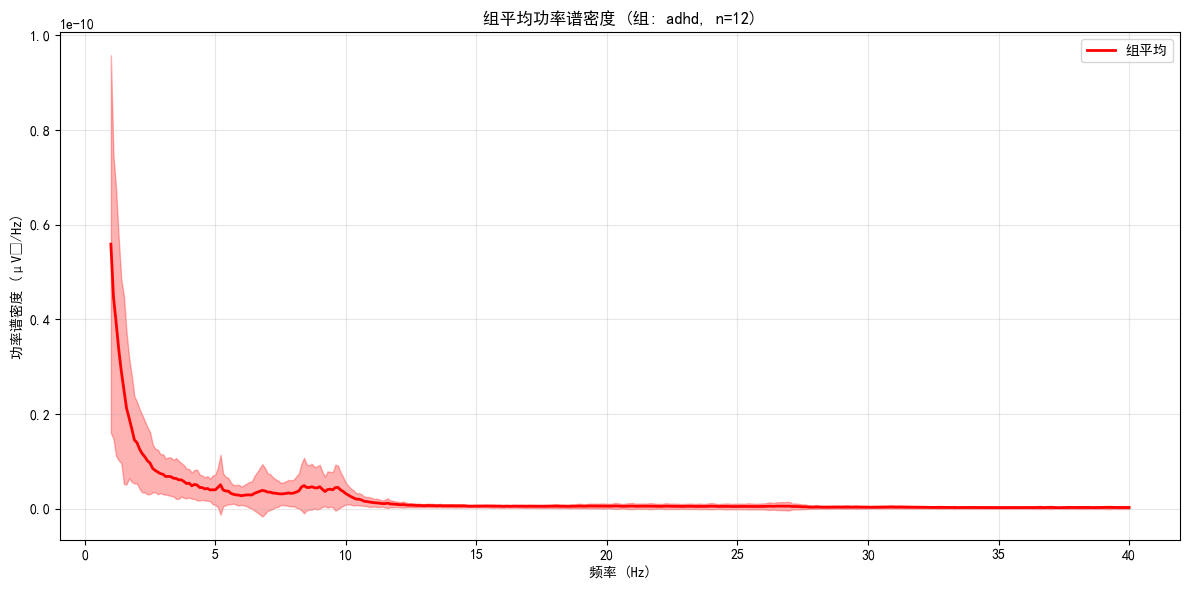

✓ 已保存: d:\LYW\REST_COM\analysis\频域分析\adhd\figures\group_psd.png


In [95]:
# =============================================================================
# 可视化PSD组平均
# =============================================================================
# 变量血缘 (Data Lineage):
#   psd_mean ← psds_group.mean(axis=0)
#     └── psds_group ← np.array(list_psds).mean(axis=0)
#           └── list_psds ← [compute_psd(epochs) for epochs in all_subjects]
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 6))
psd_mean = psds_group.mean(axis=0)
psd_std = psds_group_std.mean(axis=0)
ax.plot(freqs, psd_mean, color="red", linewidth=2, label="组平均")
ax.fill_between(freqs, psd_mean - psd_std, psd_mean + psd_std, alpha=0.3, color="red")
ax.set_xlabel("频率 (Hz)")
ax.set_ylabel("功率谱密度 (μV²/Hz)")
ax.set_title(f"组平均功率谱密度 (组: {GROUP_NAME}, n={success_count})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'group_psd.png', dpi=150, bbox_inches="tight")
plt.show()

print(f"✓ 已保存: {FIGURES_PATH / 'group_psd.png'}")

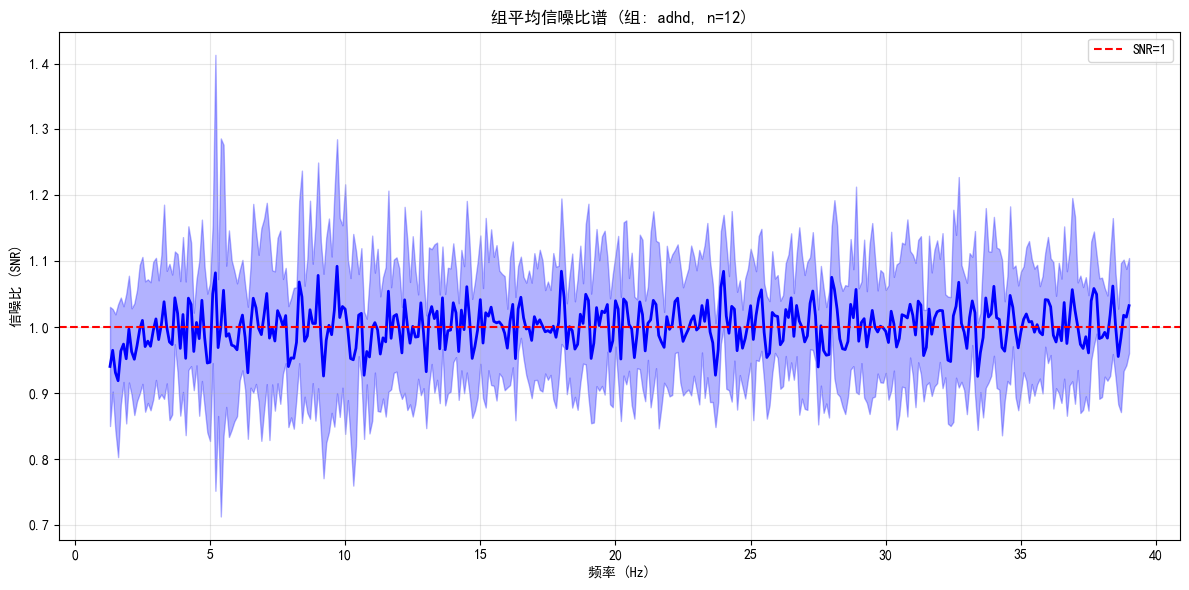

✓ 已保存: d:\LYW\REST_COM\analysis\频域分析\adhd\figures\group_snr.png


In [96]:
# =============================================================================
# 可视化SNR组平均
# =============================================================================
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(freqs_snr, snr_group_mean, color="blue", linewidth=2)
ax.fill_between(freqs_snr, snr_group_mean - snr_group_std, 
                snr_group_mean + snr_group_std, alpha=0.3, color="blue")
ax.axhline(y=1, color="red", linestyle="--", label="SNR=1")
ax.set_xlabel("频率 (Hz)")
ax.set_ylabel("信噪比 (SNR)")
ax.set_title(f"组平均信噪比谱 (组: {GROUP_NAME}, n={success_count})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'group_snr.png', dpi=150, bbox_inches="tight")
plt.show()

print(f"✓ 已保存: {FIGURES_PATH / 'group_snr.png'}")

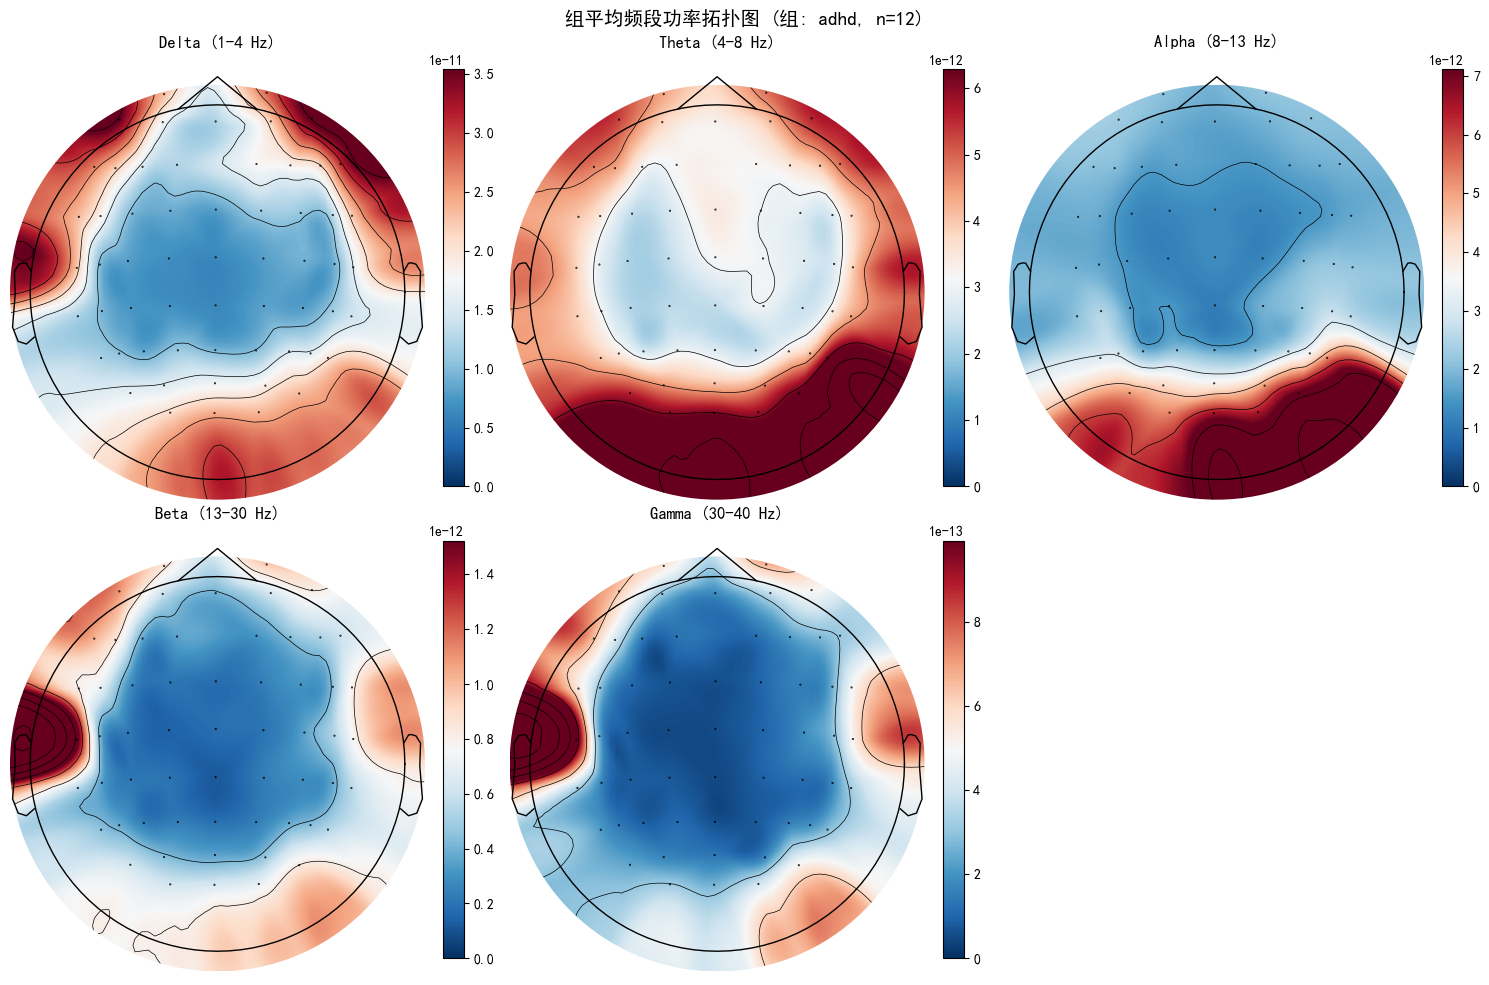

✓ 已保存: d:\LYW\REST_COM\analysis\频域分析\adhd\figures\group_band_powers.png


In [97]:
# =============================================================================
# 可视化频段功率组平均拓扑图
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (band_name, band_power) in enumerate(band_powers_group.items()):
    if idx < len(axes):
        im, _ = mne.viz.plot_topomap(
            band_power, epochs.info, axes=axes[idx],
            show=False, cmap="RdBu_r"
        )
        axes[idx].set_title(f"{band_name} ({BANDS[band_name][0]}-{BANDS[band_name][1]} Hz)")
        plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)

axes[-1].axis("off")
plt.suptitle(f"组平均频段功率拓扑图 (组: {GROUP_NAME}, n={success_count})", fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'group_band_powers.png', dpi=150, bbox_inches="tight")
plt.show()

print(f"✓ 已保存: {FIGURES_PATH / 'group_band_powers.png'}")

## 描述性统计

In [98]:
# 计算各频段功率的描述性统计
stats_data = []
for band_name in BANDS.keys():
    band_data = np.array([bp[band_name] for bp in list_band_powers])
    # 跨被试和通道平均
    band_mean = band_data.mean()
    band_std = band_data.std()
    stats_data.append({
        "频段": band_name,
        "频率范围": f"{BANDS[band_name][0]}-{BANDS[band_name][1]} Hz",
        "平均功率": f"{band_mean:.2e}",
        "标准差": f"{band_std:.2e}"
    })

stats_df = pd.DataFrame(stats_data)
print(f"频段功率描述性统计 (组: {GROUP_NAME}):")
display(stats_df)

# 保存统计结果
stats_df.to_csv(RESULTS_PATH / 'frequency_stats.csv', index=False)
print(f"\n✓ 已保存: {RESULTS_PATH / 'frequency_stats.csv'}")

# =============================================================================
# 保存被试级频段功率 (跨通道平均，用于组间统计比较)
# =============================================================================
subject_band_rows = []
for i, bp in enumerate(list_band_powers):
    info = list_subject_info[i]
    row = {
        'subject_id': info['subject_id'],
        'group': GROUP_NAME,
    }
    for band_name in BANDS.keys():
        # bp[band_name] shape: (n_channels,) → 跨通道平均得到标量
        row[band_name] = float(bp[band_name].mean())
    subject_band_rows.append(row)

subject_band_df = pd.DataFrame(subject_band_rows)
subject_band_df.to_csv(RESULTS_PATH / 'subject_band_powers.csv', index=False)
print(f"✓ 已保存被试级频段功率: {RESULTS_PATH / 'subject_band_powers.csv'}")
print(f"  shape: {subject_band_df.shape} (被试数 × [id, group, 5频段])")
display(subject_band_df)

频段功率描述性统计 (组: adhd):


,频段,频率范围,平均功率,标准差
0,Delta,1-4 Hz,1.51e-11,1.36e-11
1,Theta,4-8 Hz,3.66e-12,2.94e-12
2,Alpha,8-13 Hz,2.41e-12,2.43e-12
3,Beta,13-30 Hz,4.73e-13,7.30e-13
4,Gamma,30-40 Hz,2.44e-13,4.70e-13



✓ 已保存: d:\LYW\REST_COM\analysis\频域分析\adhd\results\frequency_stats.csv
✓ 已保存被试级频段功率: d:\LYW\REST_COM\analysis\频域分析\adhd\results\subject_band_powers.csv
  shape: (12, 7) (被试数 × [id, group, 5频段])


,subject_id,group,Delta,Theta,Alpha,Beta,Gamma
0,018,adhd,2.813040e-11,3.262314e-12,1.681465e-12,2.464228e-13,6.749327e-14
1,029,adhd,1.199479e-11,5.302395e-12,1.799600e-12,3.183868e-13,8.900980e-14
2,031,adhd,1.109306e-11,1.293141e-12,4.601824e-13,1.975893e-13,1.647121e-13
3,037,adhd,2.466549e-11,1.037310e-11,4.341498e-12,1.448976e-12,8.100163e-13
4,038,adhd,9.824419e-12,3.154986e-12,2.931533e-12,4.089642e-13,2.397410e-13
5,045,adhd,1.511642e-11,2.489952e-12,1.452598e-12,8.847254e-13,1.443711e-13
6,075,adhd,7.203212e-12,3.154650e-12,4.794012e-12,3.372872e-13,2.003742e-13
7,091,adhd,1.373537e-11,2.350189e-12,1.674427e-12,3.209840e-13,1.147847e-13
8,094,adhd,1.122045e-11,3.028677e-12,4.539055e-12,3.541810e-13,1.399173e-13
9,117,adhd,6.873603e-12,1.676315e-12,8.034146e-13,1.913897e-13,1.442670e-13


## 保存组分析结果

In [99]:
# 保存组分析结果
group_results = {
    "group_name": GROUP_NAME,
    "n_subjects": success_count,
    "subject_info": subject_info_df.to_dict(),
    "psd_group": {"mean": psds_group, "std": psds_group_std, "freqs": freqs},
    "snr_group": {"mean": snr_group_mean, "std": snr_group_std, "freqs": freqs_snr},
    "band_powers_group": {"mean": band_powers_group, "std": band_powers_group_std},
    "relative_powers_group": relative_powers_group,
    "bands": BANDS,
    "statistics": stats_df.to_dict()
}

result_file = RESULTS_PATH / 'group_frequency_results.pkl'
with open(result_file, "wb") as f:
    pickle.dump(group_results, f)

# 保存被试信息
subject_info_df.to_csv(RESULTS_PATH / 'subject_info.csv', index=False)

print("=" * 60)
print(f"频域分析完成! (组: {GROUP_NAME})")
print("=" * 60)
print(f"\n结果包含:")
print(f"  - 分析组: {GROUP_NAME}")
print(f"  - 被试数: {success_count}")
print(f"  - PSD组平均: {psds_group.shape}")
print(f"  - SNR组平均: {snr_group_mean.shape}")
print(f"  - 频段功率: {len(band_powers_group)} 个频段")

print(f"\n输出文件:")
for f in RESULTS_PATH.glob('*'):
    print(f"  - {f.name}")

print(f"\n可视化文件:")
for f in FIGURES_PATH.glob('*'):
    print(f"  - {f.name}")

频域分析完成! (组: adhd)

结果包含:
  - 分析组: adhd
  - 被试数: 12
  - PSD组平均: (59, 391)
  - SNR组平均: (381,)
  - 频段功率: 5 个频段

输出文件:
  - frequency_stats.csv
  - group_frequency_results.pkl
  - subject_band_powers.csv
  - subject_info.csv

可视化文件:
  - group_band_powers.png
  - group_psd.png
  - group_snr.png
